# Aggregated MALS Result Plots

Reads `result/plot/aggregated-direct` and `result/plot/aggregated-materialized` using the shared structures from `scripts/common.py`, then plots the main metrics with matplotlib.

Metrics shown: `identifier_f1`, `edit_similarity`, and `hallucination_rate`.


In [23]:
from __future__ import annotations

from dataclasses import dataclass, replace
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'result').exists() and (candidate / 'scripts' / 'common.py').exists():
            return candidate
    raise RuntimeError('Could not find repo root')

ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.common import (
    read_direct_aggregation_result,
    read_materialized_aggregation_result,
)

PLOT_ROOT = ROOT / 'result' / 'plot'
DIRECT_ROOT = PLOT_ROOT / 'aggregated-direct'
MATERIALIZED_ROOT = PLOT_ROOT / 'aggregated-materialized'

SERVER_LABELS = {'mals-adapter': 'mals'}
SERVER_COLORS = {'mals': '#2f6f73', 'lsp-ai': '#d17a22', 'llm-ls': '#695bb8'}

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25


In [24]:
@dataclass(frozen=True)
class DirectMetricRow:
    dataset: str
    language: str
    server: str
    count: int
    identifier_f1: float
    edit_similarity: float
    exact_match: float

@dataclass(frozen=True)
class MaterializedDiagnosticRow:
    dataset: str
    language: str
    server: str
    count: int
    hallucination_rate: float
    new_diagnostic_count: float
    completion_diagnostic_count: float

@dataclass(frozen=True)
class MetricRow:
    dataset: str = ''
    language: str = ''
    server: str = ''
    count: int = 0
    identifier_f1: float | None = None
    edit_similarity: float | None = None
    exact_match: float | None = None
    hallucination_rate: float | None = None
    new_diagnostic_count: float | None = None
    completion_diagnostic_count: float | None = None
    label: str = ''

def server_label(value: str) -> str:
    return SERVER_LABELS.get(value, value)

def load_direct_rows(root: Path) -> list[DirectMetricRow]:
    rows = []
    for path in sorted(root.glob('*/*.json')):
        result = read_direct_aggregation_result(path)
        for item in result.summary:
            dataset = item.group.get('dataset') or path.parent.name
            language = item.group.get('language') or ''
            server = server_label(item.group.get('server') or path.stem)
            rows.append(DirectMetricRow(
                dataset=dataset,
                language=language,
                server=server,
                count=item.count,
                identifier_f1=item.best_metrics.identifier_f1,
                edit_similarity=item.best_metrics.edit_similarity,
                exact_match=item.best_metrics.exact_match,
            ))
    return rows

def load_materialized_rows(root: Path) -> list[MaterializedDiagnosticRow]:
    rows = []
    for path in sorted(root.glob('*/*.json')):
        result = read_materialized_aggregation_result(path)
        for item in result.summary:
            if item.completion_count == 0:
                continue
            dataset = item.group.get('dataset') or path.parent.name
            language = item.group.get('language') or ''
            server = server_label(item.group.get('server') or path.stem)
            rows.append(MaterializedDiagnosticRow(
                dataset=dataset,
                language=language,
                server=server,
                count=item.count,
                hallucination_rate=item.best_hallucination_rate,
                new_diagnostic_count=item.best_new_diagnostic_count,
                completion_diagnostic_count=item.best_completion_diagnostic_count,
            ))
    return rows

direct_rows = load_direct_rows(DIRECT_ROOT)
materialized_rows = load_materialized_rows(MATERIALIZED_ROOT)

print(f"direct rows: {len(direct_rows)}")
print(f"materialized rows: {len(materialized_rows)}")
print('datasets:', sorted({r.dataset for r in direct_rows + materialized_rows}))
print('servers:', sorted({r.server for r in direct_rows + materialized_rows}))


direct rows: 36
materialized rows: 36
datasets: ['cceval', 'humanevalpack', 'repobench-c']
servers: ['llm-ls', 'lsp-ai', 'mals']


In [25]:
def weighted_mean(items: list[MetricRow], metric: str) -> float | None:
    values = [(getattr(row, metric), row.count or 1) for row in items if getattr(row, metric) is not None]
    if not values:
        return None
    total = sum(weight for _, weight in values)
    return sum(value * weight for value, weight in values) / total

def aggregate(rows: list[MetricRow], group_by: list[str], metrics: list[str]) -> list[MetricRow]:
    groups = defaultdict(list)
    for row in rows:
        groups[tuple(getattr(row, field) for field in group_by)].append(row)

    result = []
    for key, items in sorted(groups.items()):
        values = {field: value for field, value in zip(group_by, key)}
        values['count'] = sum(row.count for row in items)
        values.update({metric: weighted_mean(items, metric) for metric in metrics})
        result.append(MetricRow(**values))
    return result

def join_metric_rows() -> list[MetricRow]:
    rows = {
        (r.dataset, r.language, r.server): MetricRow(
            dataset=r.dataset,
            language=r.language,
            server=r.server,
            count=r.count,
            identifier_f1=r.identifier_f1,
            edit_similarity=r.edit_similarity,
            exact_match=r.exact_match,
        )
        for r in direct_rows
    }
    for row in materialized_rows:
        key = (row.dataset, row.language, row.server)
        current = rows.get(key, MetricRow(dataset=row.dataset, language=row.language, server=row.server, count=row.count))
        rows[key] = replace(
            current,
            count=max(current.count, row.count),
            hallucination_rate=row.hallucination_rate,
            new_diagnostic_count=row.new_diagnostic_count,
            completion_diagnostic_count=row.completion_diagnostic_count,
        )
    return sorted(rows.values(), key=lambda r: (r.dataset, r.language, r.server))

metric_rows = join_metric_rows()
metric_rows[:3]


[MetricRow(dataset='cceval', language='csharp', server='llm-ls', count=12, identifier_f1=0.39087301587301587, edit_similarity=0.4193553470262888, exact_match=0.0, hallucination_rate=0.8333333333333334, new_diagnostic_count=21.666666666666668, completion_diagnostic_count=23.25, label=''),
 MetricRow(dataset='cceval', language='csharp', server='lsp-ai', count=20, identifier_f1=0.5846647193386324, edit_similarity=0.48157317869268784, exact_match=0.05, hallucination_rate=0.85, new_diagnostic_count=20.3, completion_diagnostic_count=24.75, label=''),
 MetricRow(dataset='cceval', language='csharp', server='mals', count=20, identifier_f1=0.49632167349558654, edit_similarity=0.41247684427305825, exact_match=0.0, hallucination_rate=1.0, new_diagnostic_count=23.2, completion_diagnostic_count=24.15, label='')]

In [26]:
def plot_grouped_bars(rows: list[MetricRow], metric: str, title: str, x_field: str = "label"):
    rows = [row for row in rows if getattr(row, metric) is not None]
    labels = sorted({getattr(row, x_field) for row in rows})
    servers = sorted({row.server for row in rows})
    values = {(getattr(row, x_field), row.server): getattr(row, metric) for row in rows}

    if not labels:
        print(f"No data for {metric}")
        return

    width = 0.8 / max(len(servers), 1)
    x = list(range(len(labels)))
    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 0.8), 5))

    for i, server in enumerate(servers):
        offset = (i - (len(servers) - 1) / 2) * width
        y = [values.get((label, server), 0) for label in labels]
        xpos = [pos + offset for pos in x]
        color = SERVER_COLORS.get(server)
        ax.bar(xpos, y, width, label=server, color=color, edgecolor='black', linewidth=0.4)
        if metric == 'hallucination_rate':
            zero_x = [pos for pos, value in zip(xpos, y) if value == 0]
            if zero_x:
                ax.scatter(zero_x, [0] * len(zero_x), marker='_', s=180, color=color, linewidths=2.5, zorder=3)

    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    if all((getattr(row, metric) is None or 0 <= getattr(row, metric) <= 1) for row in rows):
        ax.set_ylim(-0.1 if metric == 'hallucination_rate' else 0, 1)
    ax.legend()
    fig.tight_layout()
    plt.show()

def add_label(rows: list[MetricRow], *fields: str) -> list[MetricRow]:
    return [
        replace(row, label=' / '.join(str(getattr(row, field)) for field in fields if getattr(row, field)))
        for row in rows
    ]


## Per Dataset / Language


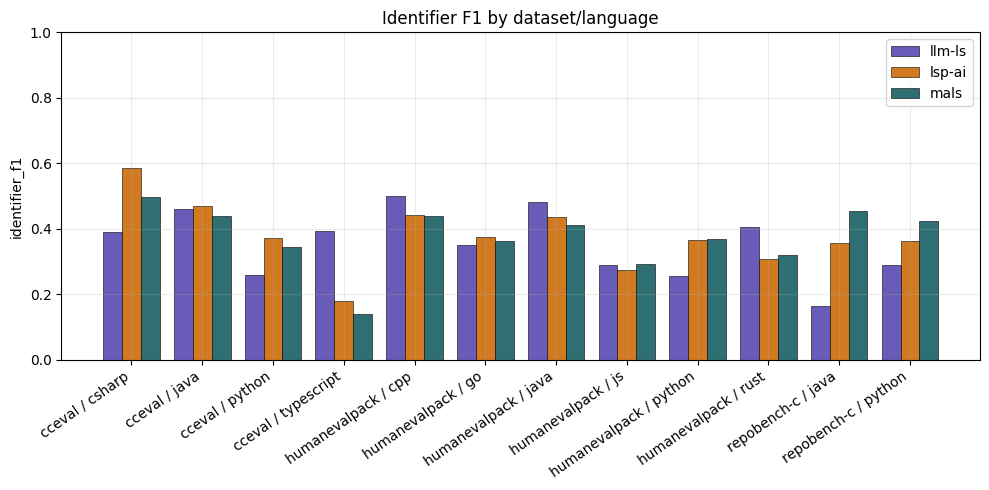

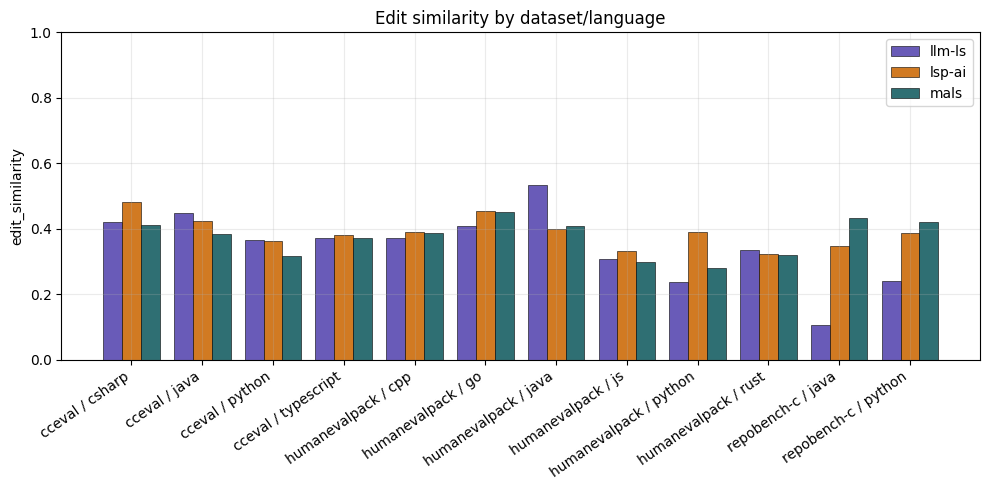

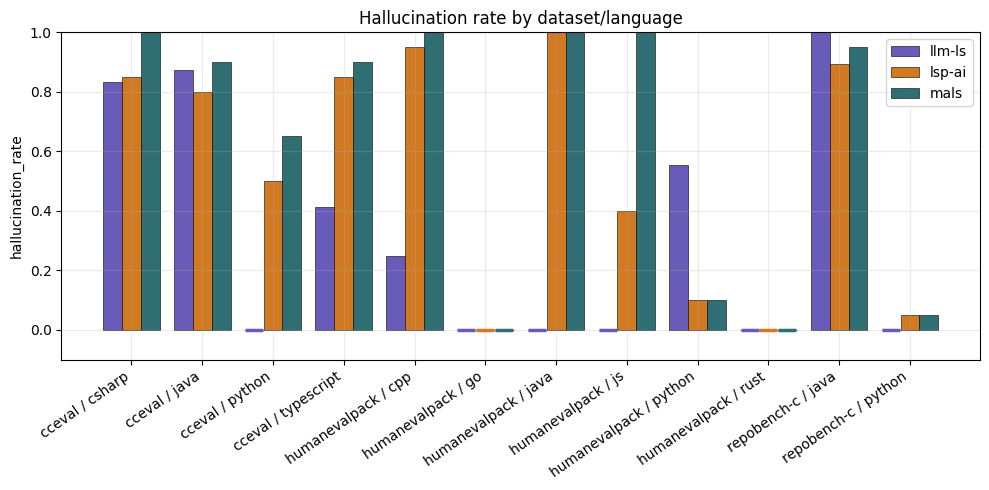

In [27]:
language_rows = add_label(metric_rows, 'dataset', 'language')
plot_grouped_bars(language_rows, 'identifier_f1', 'Identifier F1 by dataset/language')
plot_grouped_bars(language_rows, 'edit_similarity', 'Edit similarity by dataset/language')
plot_grouped_bars(language_rows, 'hallucination_rate', 'Hallucination rate by dataset/language')


## Aggregated Across Languages


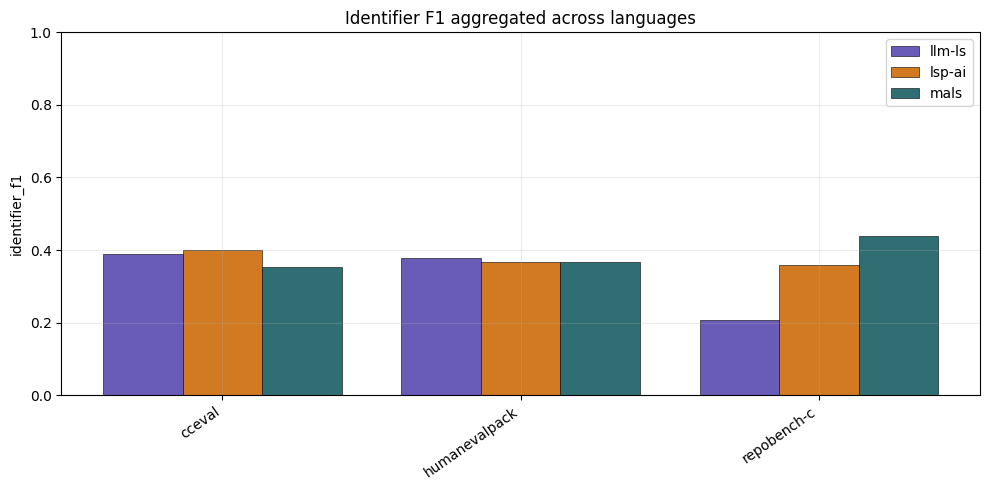

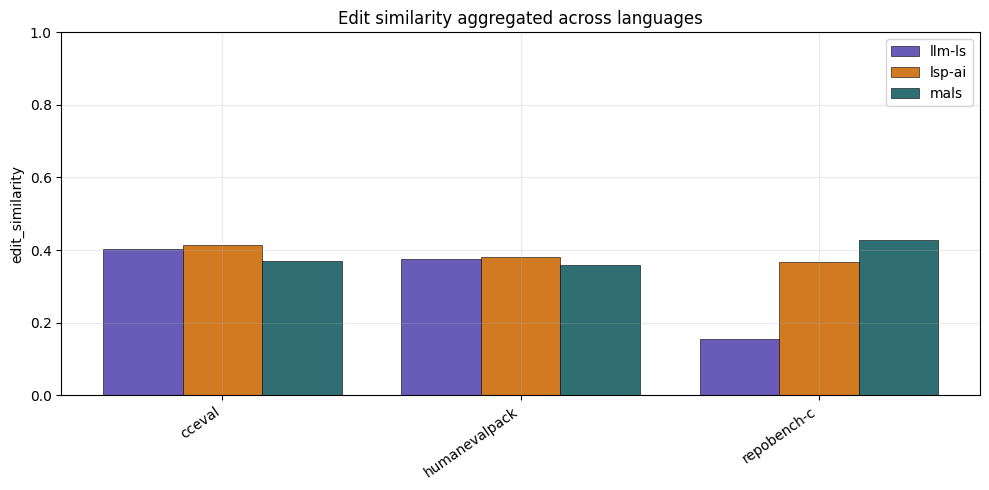

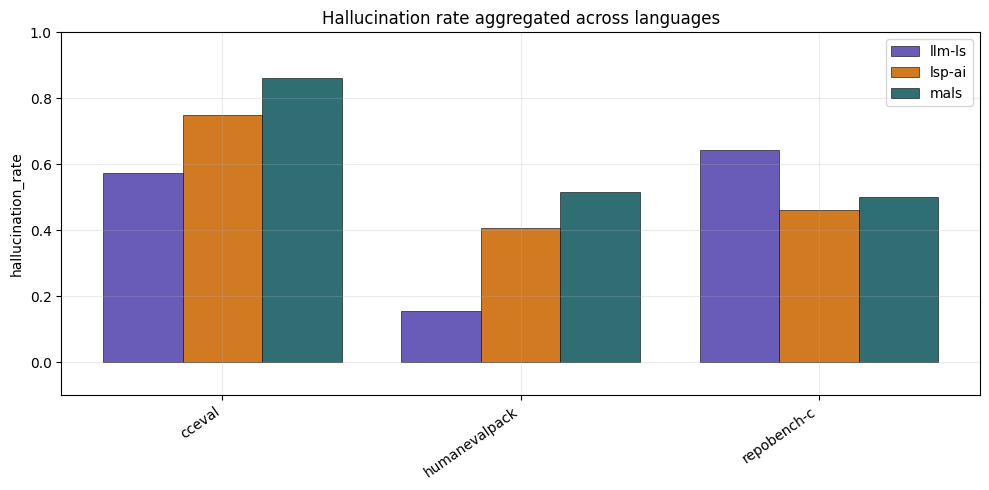

[MetricRow(dataset='cceval', language='', server='llm-ls', count=54, identifier_f1=0.39043459084854576, edit_similarity=0.4033800813299087, exact_match=None, hallucination_rate=0.5740740740740741, new_diagnostic_count=None, completion_diagnostic_count=None, label='cceval'),
 MetricRow(dataset='cceval', language='', server='lsp-ai', count=80, identifier_f1=0.4010411552204694, edit_similarity=0.41261494757509576, exact_match=None, hallucination_rate=0.75, new_diagnostic_count=None, completion_diagnostic_count=None, label='cceval'),
 MetricRow(dataset='cceval', language='', server='mals', count=80, identifier_f1=0.35453031569879395, edit_similarity=0.3711678139760776, exact_match=None, hallucination_rate=0.8625, new_diagnostic_count=None, completion_diagnostic_count=None, label='cceval'),
 MetricRow(dataset='humanevalpack', language='', server='llm-ls', count=97, identifier_f1=0.3791052097230102, edit_similarity=0.3752250073952897, exact_match=None, hallucination_rate=0.15463917525773196,

In [28]:
dataset_rows = aggregate(metric_rows, ['dataset', 'server'], ['identifier_f1', 'edit_similarity', 'hallucination_rate'])
dataset_rows = add_label(dataset_rows, 'dataset')
plot_grouped_bars(dataset_rows, 'identifier_f1', 'Identifier F1 aggregated across languages')
plot_grouped_bars(dataset_rows, 'edit_similarity', 'Edit similarity aggregated across languages')
plot_grouped_bars(dataset_rows, 'hallucination_rate', 'Hallucination rate aggregated across languages')
dataset_rows


## Overall Server Comparison


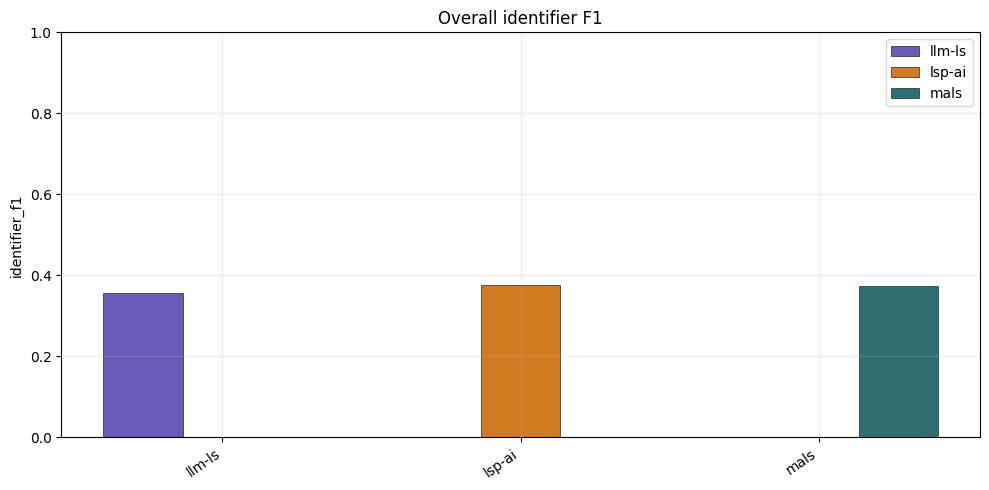

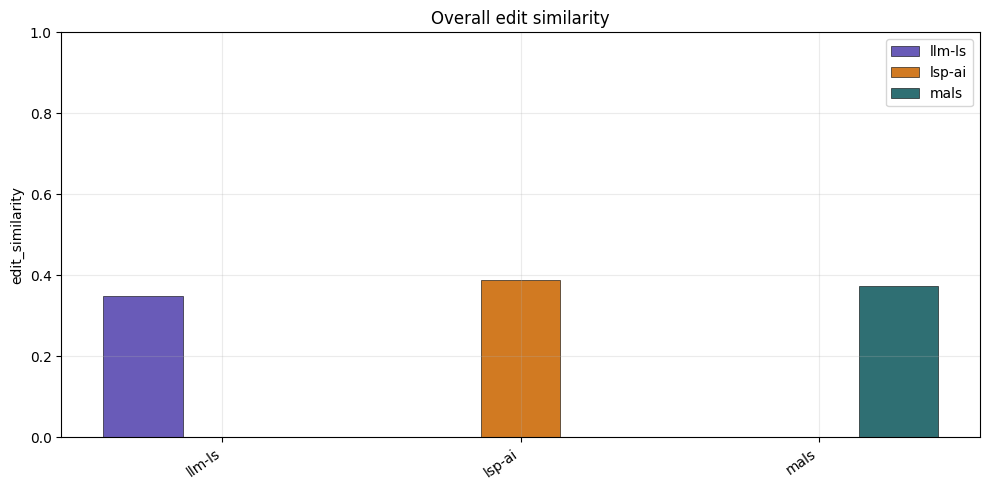

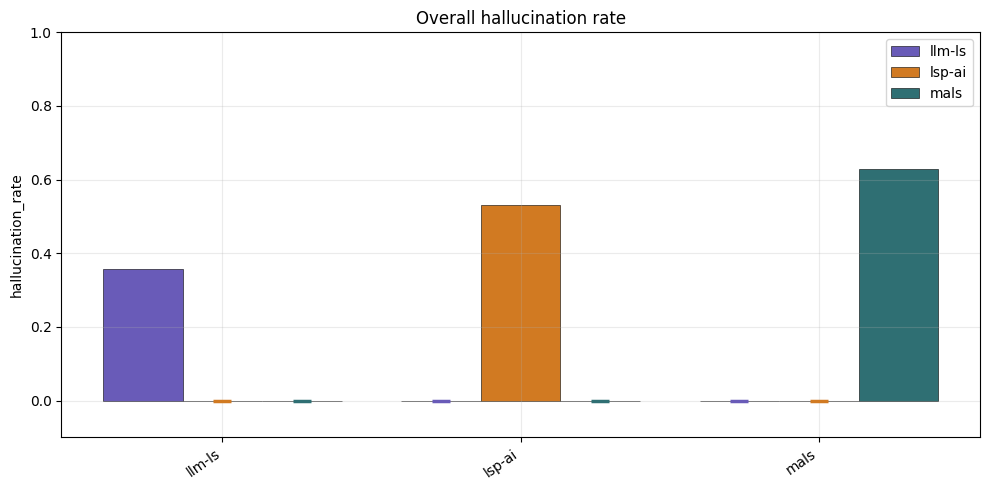

[MetricRow(dataset='', language='', server='llm-ls', count=179, identifier_f1=0.35566156925607006, edit_similarity=0.3491087582750851, exact_match=None, hallucination_rate=0.3575418994413408, new_diagnostic_count=None, completion_diagnostic_count=None, label='llm-ls'),
 MetricRow(dataset='', language='', server='lsp-ai', count=239, identifier_f1=0.3772299938761018, edit_similarity=0.3895391335884287, exact_match=None, hallucination_rate=0.5313807531380753, new_diagnostic_count=None, completion_diagnostic_count=None, label='lsp-ai'),
 MetricRow(dataset='', language='', server='mals', count=240, identifier_f1=0.3743912908800528, edit_similarity=0.3737922812034141, exact_match=None, hallucination_rate=0.6291666666666667, new_diagnostic_count=None, completion_diagnostic_count=None, label='mals')]

In [29]:
overall_rows = aggregate(metric_rows, ['server'], ['identifier_f1', 'edit_similarity', 'hallucination_rate'])
overall_rows = add_label(overall_rows, 'server')
plot_grouped_bars(overall_rows, 'identifier_f1', 'Overall identifier F1')
plot_grouped_bars(overall_rows, 'edit_similarity', 'Overall edit similarity')
plot_grouped_bars(overall_rows, 'hallucination_rate', 'Overall hallucination rate')
overall_rows


## Diagnostics


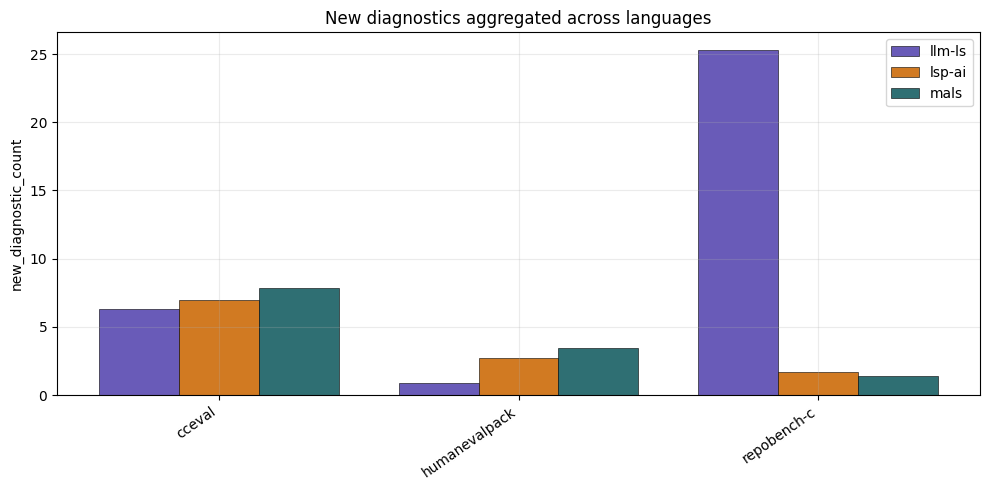

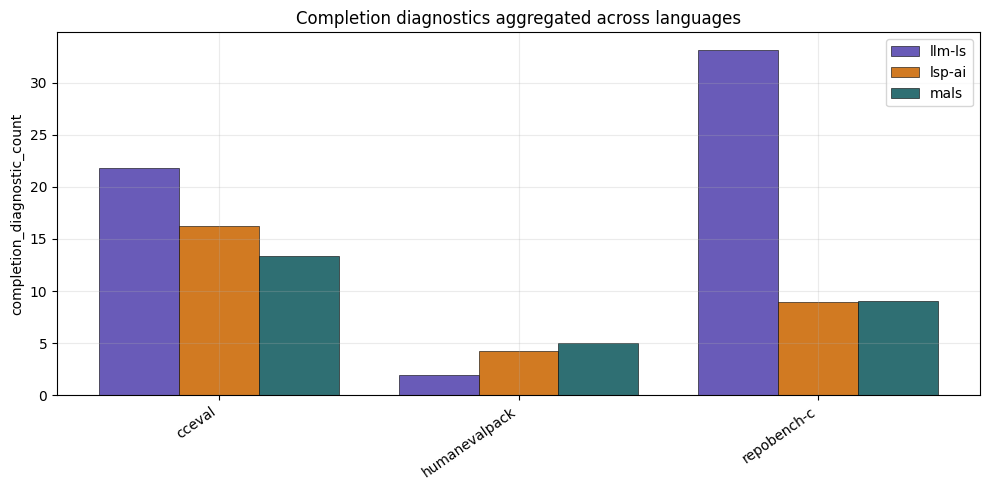

[MetricRow(dataset='cceval', language='', server='llm-ls', count=54, identifier_f1=None, edit_similarity=None, exact_match=None, hallucination_rate=None, new_diagnostic_count=6.333333333333333, completion_diagnostic_count=21.77777777777778, label='cceval'),
 MetricRow(dataset='cceval', language='', server='lsp-ai', count=80, identifier_f1=None, edit_similarity=None, exact_match=None, hallucination_rate=None, new_diagnostic_count=6.975, completion_diagnostic_count=16.275, label='cceval'),
 MetricRow(dataset='cceval', language='', server='mals', count=80, identifier_f1=None, edit_similarity=None, exact_match=None, hallucination_rate=None, new_diagnostic_count=7.8375, completion_diagnostic_count=13.4125, label='cceval'),
 MetricRow(dataset='humanevalpack', language='', server='llm-ls', count=97, identifier_f1=None, edit_similarity=None, exact_match=None, hallucination_rate=None, new_diagnostic_count=0.9072164948453608, completion_diagnostic_count=1.9793814432989691, label='humanevalpack')

In [30]:
diagnostic_rows = aggregate(metric_rows, ['dataset', 'server'], ['new_diagnostic_count', 'completion_diagnostic_count'])
diagnostic_rows = add_label(diagnostic_rows, 'dataset')
plot_grouped_bars(diagnostic_rows, 'new_diagnostic_count', 'New diagnostics aggregated across languages')
plot_grouped_bars(diagnostic_rows, 'completion_diagnostic_count', 'Completion diagnostics aggregated across languages')
diagnostic_rows
